Importação das bibliotecas necessárias

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
from scipy.io.wavfile import read, write
from numpy.fft import fft, fftfreq, fftshift
from IPython.display import Audio as play

warnings.filterwarnings("ignore")

Análise dos áudios

In [73]:
play("./data/01.wav")

In [74]:
play("./data/02.wav")

Definição de funções importantes:

In [360]:
def audio_info(data_audio:str):
    sample_rate, data = read(data_audio)
    N = len(data)
    T = 1/sample_rate
    t = np.arange(0, N/sample_rate, T)
    print(f"Número de amostras: {sample_rate}\nTamanho do sinal: {N}\nVetor tempo: {t}")

    return sample_rate, data, N, T, t

def convert_to_jw(N:int, T:float, data_audio:list) -> np.array:
    f = fftfreq(N, T)
    transf = np.abs(fft(data_audio))
    return f, transf

def spectrum(x_freq):
    x_magnitude = np.abs(x_freq)  
    x_magnitude /= np.max(x_magnitude)  
    return 20 * np.log10(x_magnitude) 

def savefig(fig, url_save) -> None:
    fig.tight_layout()
    plt.savefig(url_save)
    print(f"Imagem salva em: {url_save}")

#### 1. Ler o arquivo .wav para obter o sinal x[n] em forma de vetor.

In [394]:
# Obtaining x[n] in vector form from 01.wav file.
audio_1_path = "./data/01.wav"
audio_2_path = "./data/02.wav"

sample_rate, data, N, T, t = audio_info(audio_1_path)
print("------------------------------")
sample_rate_2, data_2, N_2, T_2, t_2 = audio_info(audio_2_path)

Número de amostras: 44100
Tamanho do sinal: 622173
Vetor tempo: [0.00000000e+00 2.26757370e-05 4.53514739e-05 ... 1.41081633e+01
 1.41081859e+01 1.41082086e+01]
------------------------------
Número de amostras: 22050
Tamanho do sinal: 300449
Vetor tempo: [0.00000000e+00 4.53514739e-05 9.07029478e-05 ... 1.36256689e+01
 1.36257143e+01 1.36257596e+01]


#### 2. Plotar o gráfico de x[n] no tempo e de seu espectro de frequência.

In [399]:
def signal_raw(title, t, data, savefig_path):
    """
    Args:
        title -> título do gráfico
        t -> vetor tempo
        data -> sinal original x[n]
        savefig_path -> caminho para salvar as imagens
    Return: 
        None
    """
    # Plotando gráfico do sinal no tempo e na frequência
    fig, ax = plt.subplots(figsize=(8,6))

    ax.plot(t, data)
    ax.set_title(title)
    ax.set_xlabel("Tempo (s)")
    ax.set_ylabel("Amplitude")

    savefig(fig, savefig_path)
    plt.show()

def signal_spec(title, f, transf, sample_rate, savefig_path):
    """
    Args:
        title -> título do gráfico
        f -> frequências
        transf -> transformada
        title -> titulo do gráfico
        savefig_path -> caminho para salvar as imagens
    Return: 
        None
    """
    # Plotando gráfico do sinal no tempo e na frequência
    fig, ax = plt.subplots(figsize=(8,6))
    f_shifted = fftshift(f)
    transf_shifted = fftshift(spectrum(transf))
    ax.plot(f_shifted, transf_shifted)
    ax.set_title(title)
    ax.set_xlabel("Frequência (Hz)")
    ax.set_ylabel("Amplitude (dB)")
    ax.set_xlim(0, sample_rate/2)

    savefig(fig, savefig_path)
    plt.show()

In [400]:
f, transf = convert_to_jw(N, T, data)
f_2, transf_2 = convert_to_jw(N_2, T_2, data_2)

Imagem salva em: ./images/01_wav.png


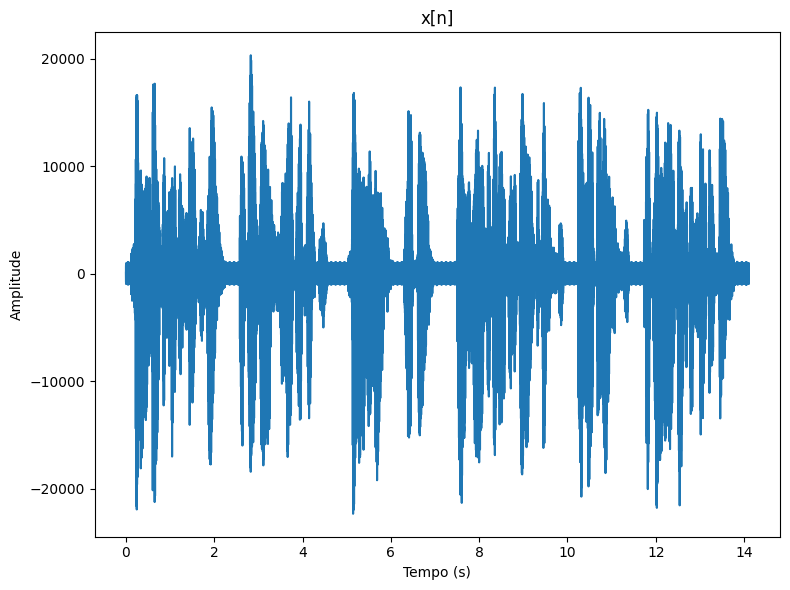

Imagem salva em: ./images/02_wav.png


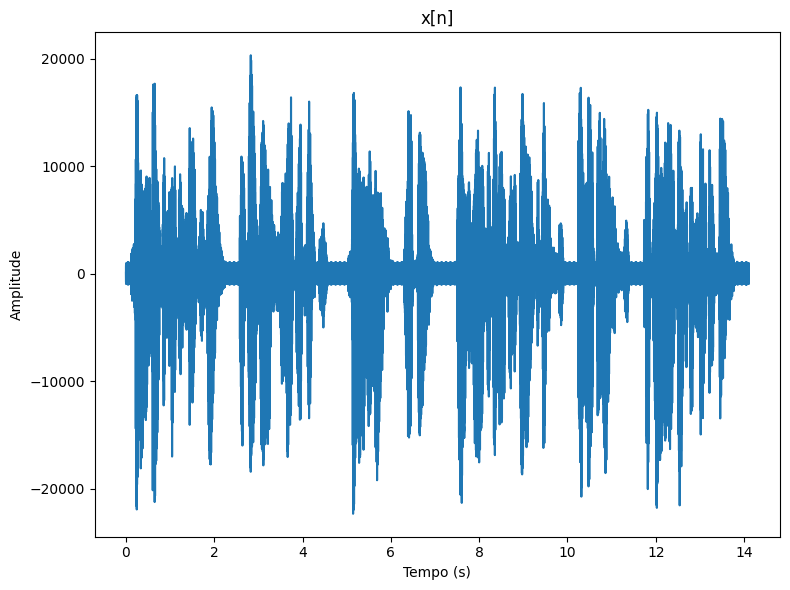

In [401]:
savefig_path = "./images/01_wav.png"
savefig_path2 = "./images/02_wav.png"

signal_raw("x[n]", t, data, savefig_path)
signal_raw("x[n]", t, data, savefig_path2)

Imagem salva em: ./images/01_wav_spec.png


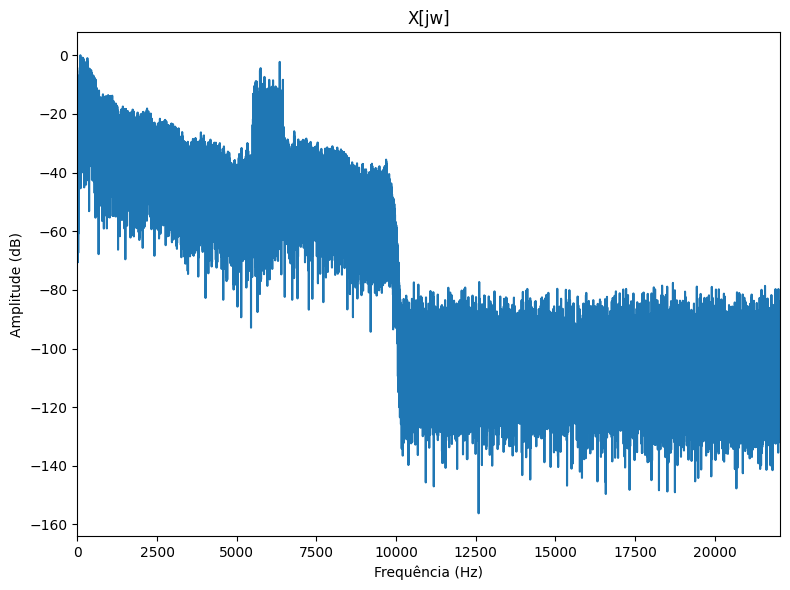

Imagem salva em: ./images/02_wav_spec.png


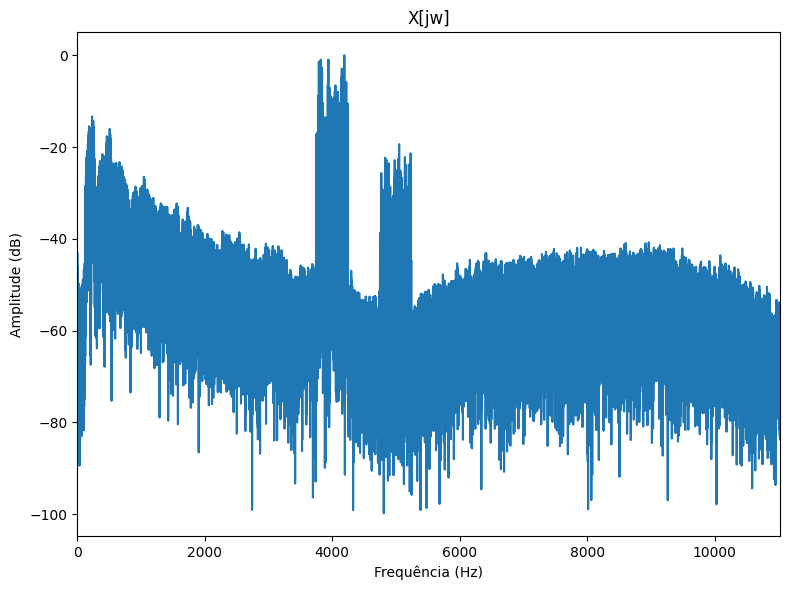

In [398]:
savefig_path = "./images/01_wav_spec.png"
savefig_path2 = "./images/02_wav_spec.png"

signal_spec("X[jw]", f, transf, sample_rate, savefig_path)
signal_spec("X[jw]", f_2, transf_2, sample_rate_2, savefig_path2)

#### 3. Implementar o filtro h[n] com os parâmetros ωc e L, tendo como base a fundamentação teórica indicada.

Sol: Para projetarmos um filtro fundamentalizado na técnica de "Window Design" (a ideia básica por trás dessa abordagem é garantir a linearidade de uma fase e a causalidade do filtro FIR h[n] através de truncamentos - janelamento), especificamente sendo passa-baixa, devemos considerar alguns fatores antes de iniciarmos, como:
- Encontrar uma função $w(n)$ suave de janelamento e definir a stopband (range no qual o sinal será atenuado ou bloqueado)
- Especificar a resposta em frequência ideal do filtro (low-pass ou passa-baixa)
- Saber que a resposta impulso idela de um filtro é dado por:
$$ h_d[n] = \text{sinc} \left( \frac{2 w_c}{\pi} (n - \alpha) \right) $$
Mas, que para obter $h_d(n)$ de um filtro FIR, temos que truncar $h_d(n)$ de ambos os lados. Para obter um filtro FIR $h(n)$ causal e de fase linear com largura $M$, nós temos que ter:
$$
h(n) =
\begin{cases} 
    h_d(n), & 0 \leq n \leq M - 1 \\
    0, & \text{elsewhere}
\end{cases}
\quad \text{and} \quad
\alpha = \frac{M - 1}{2} \tag{7.20}
$$
E então fazer $h(n) = h_d(n)w(n)$.

In [405]:
import numpy as np

def ideal_lp(wc, M):
    """
    Computa a resposta ao impulso ideal de um filtro passa-baixa.

    Args:
    wc -> frequência de corte em radianos
    M  -> comprimento do filtro (número de amostras)

    Return:
    hd -> vetor contendo a resposta ao impulso do filtro
    """
    alpha = (M - 1) / 2  # Ponto central do filtro
    n = np.arange(M)  # Vetor indo de 0 Até M-1
    m = n - alpha 
    fc = wc / np.pi  # Normaliza a frequência de corte
    
    # Calcula a resposta ao impulso usando sinc
    hd = np.sinc(2*fc * m)
    
    return hd

In [406]:
import numpy as np

def own_freqz(h, worN=8000):
    """
    Computa a resposta em frequência de um sistema discreto.

    Args:
    h -> resposta impulso
    worN ->

    Return:
    db  -> magnitude relativa em dB
    mag -> magnitude absoluta
    pha -> resposta de fase em radianos
    grd -> atraso de grupo
    w   -> amostras de frequência entre 0 e pi, de worN em worN
    """

    w = np.linspace(0, np.pi, worN)
    H = fft(h, worN)
    H = H[:worN // 2]
    w = w[:worN // 2]

    # Calcula magnitude absoluta
    mag = np.abs(H)

    # Converte magnitude para dB
    db = 20 * np.log10((mag + np.finfo(float).eps) / np.max(mag))

    # Calcula fase
    pha = np.unwrap(np.angle(H))
    pha = pha - np.mean(pha)

    # Calcula atraso de grupo
    grd = np.gradient(pha, w)

    return db, mag, pha, grd, w

In [407]:
def w_ham(M):
    n = np.arange(M)
    w = 0.54-0.46*np.cos((2*np.pi*n)/(M-1))
    return w

In [424]:
# 3. Filtro h[n]

def plot_all_vars_signal(n, hd, h, audio_title):
    # 9. Gráficos
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    ax[0].stem(n, hd)
    ax[0].set_title("Resposta Impulso Ideal")
    ax[0].set_xlabel("n")
    ax[0].set_ylabel("hd(n)")

    ax[1].stem(n, h)
    ax[1].set_title("Resposta Impulso Atual")
    ax[0].set_xlabel("n")
    ax[0].set_ylabel("h(n)")

    savefig(fig, f"images\h_n{audio_title}_amostras.png")

    plt.tight_layout()
    plt.show()

def low_pass_filter(wc:int, L:int, sample_rate:int, plot=True, audio_title=""):
    # Design low-pass filter
    wc_norm = wc / (sample_rate / 2)
    n = np.arange(L)
    # Ideal h[n]
    hd = ideal_lp(wc_norm, L)
    # Window function
    w_h = w_ham(L)
    
    h = hd*w_h
    h /= np.sum(h)
    _, mag, pha, _, w = own_freqz(h)

    if plot:
        plot_all_vars_signal(n, hd, h, audio_title)

    return h, pha, mag, w

#### 4. Plotar o gráfico de h[n] no tempo, a magnitude e a fase de sua resposta em frequência.
- Discorra sobre as diferenças observadas entre a descrição teórica e a implementação prática do filtro.

Imagem salva em: images\h_n1_amostras.png


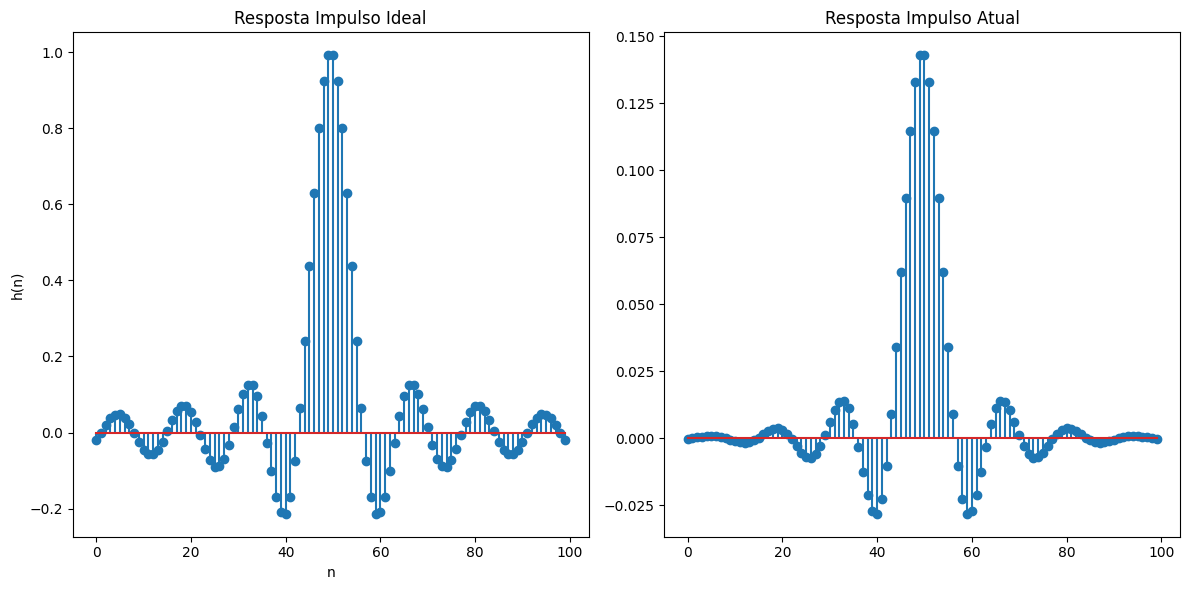

In [425]:
M=100
wc=5000
h, phase, mag, w = low_pass_filter(wc, M, sample_rate, audio_title="1")

Imagem salva em: images\h_n2_amostras.png


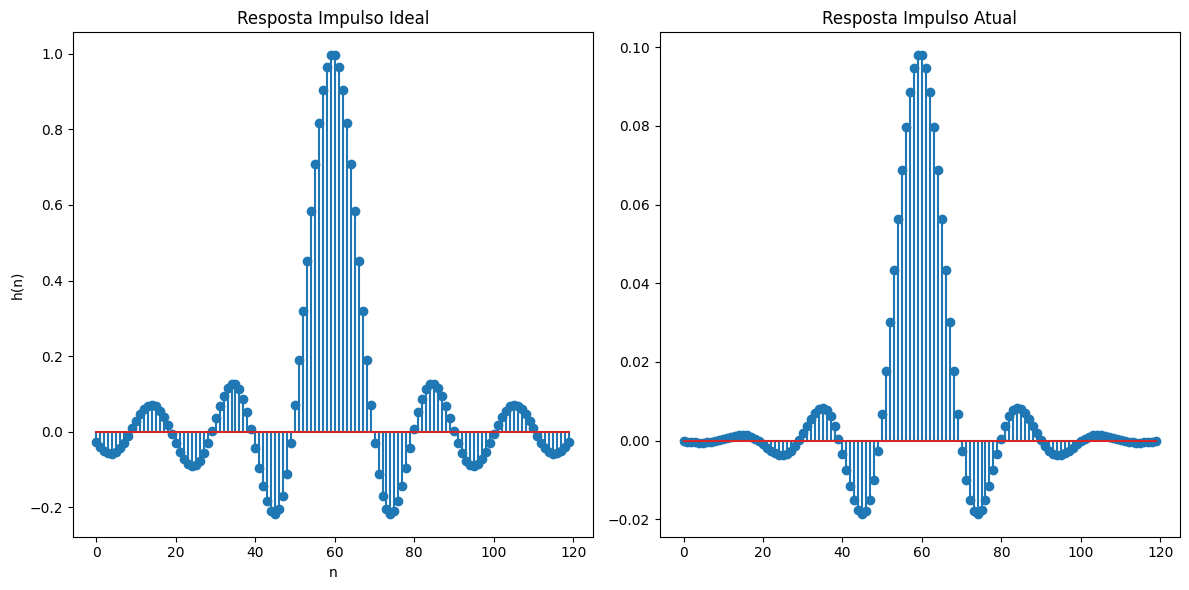

In [426]:
M=120
wc=1700
h2, phase2, mag2, w2 = low_pass_filter(wc, M, sample_rate_2, audio_title="2")

In [411]:
def plot_mag_phase_hn(audio_title, mag, phase, w, sample_rate):
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    ax[0].plot(w / np.pi, phase)
    ax[0].set_title(f"Fase do Filtro")
    ax[0].set_xlabel("Frequência (rad/amostra)")
    ax[0].set_ylabel("Fase (rad)")

    ax[1].plot(w * sample_rate / (2*np.pi), mag)
    ax[1].set_title("Magnitude")
    ax[1].set_xlabel("Frequência (Hz)")
    ax[1].set_ylabel("Magnitude")
    ax[1].set_xlim(0, sample_rate/3)

    savefig(fig, f"images\mag_phase_{audio_title}.png")

    plt.tight_layout()
    plt.show()

T = 1/sample_rate
M = 100
t = np.arange(0, M/sample_rate, T)

T = 1/sample_rate_2
M = 120
t_2 = np.arange(0, M/sample_rate_2, T)

h_normalized = h / np.max(np.abs(h))
h2_normalized = h2 / np.max(np.abs(h2))

Imagem salva em: images\filter_hns_tempo.png


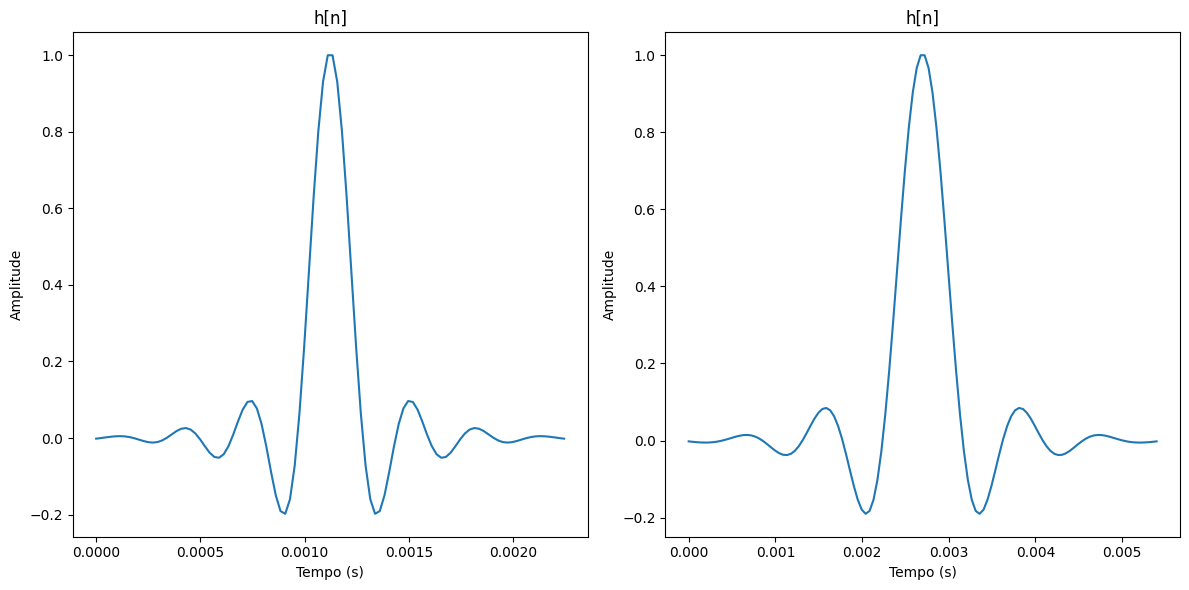

In [429]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].plot(t, h_normalized)
ax[0].set_title(f"h[n]")
ax[0].set_xlabel("Tempo (s)")
ax[0].set_ylabel("Amplitude")

ax[1].plot(t_2, h2_normalized)
ax[1].set_title("h[n]")
ax[1].set_xlabel("Tempo (s)")
ax[1].set_ylabel("Amplitude")

savefig(fig, f"images\\filter_hns_tempo.png")

plt.tight_layout()
plt.show()

#signal_raw("h[n]", t, h_normalized, savefig_path="./images/filter_hn1.png")
#signal_raw("h[n]", t_2, h2_normalized, savefig_path="./images/filter_hn2.png")

Imagem salva em: images\mag_phase_1.png


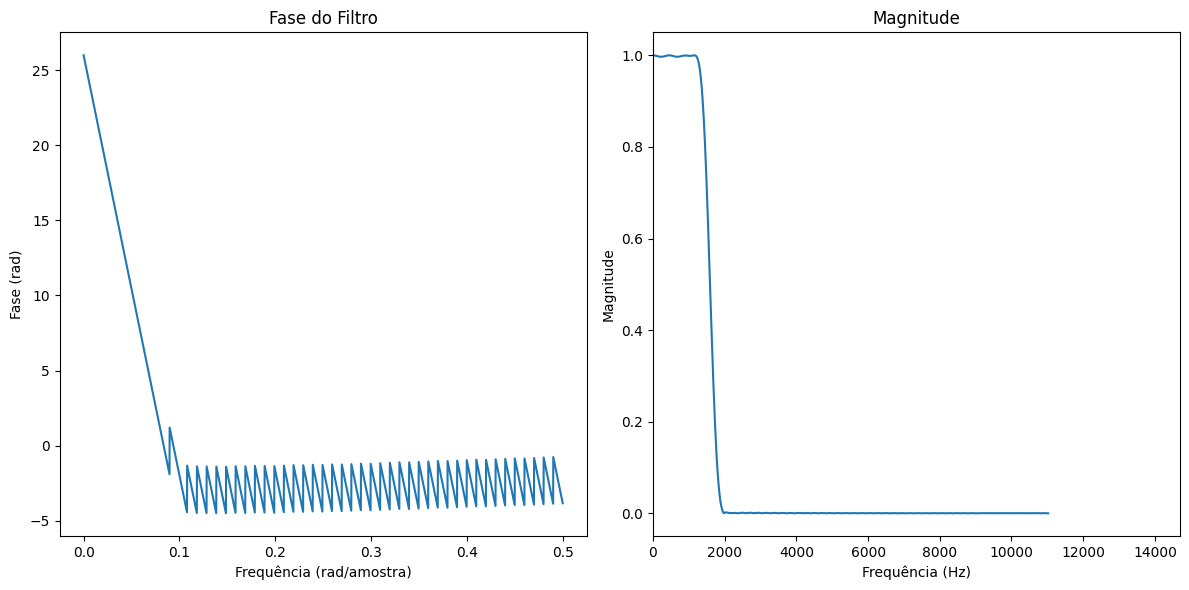

Imagem salva em: images\mag_phase_2.png


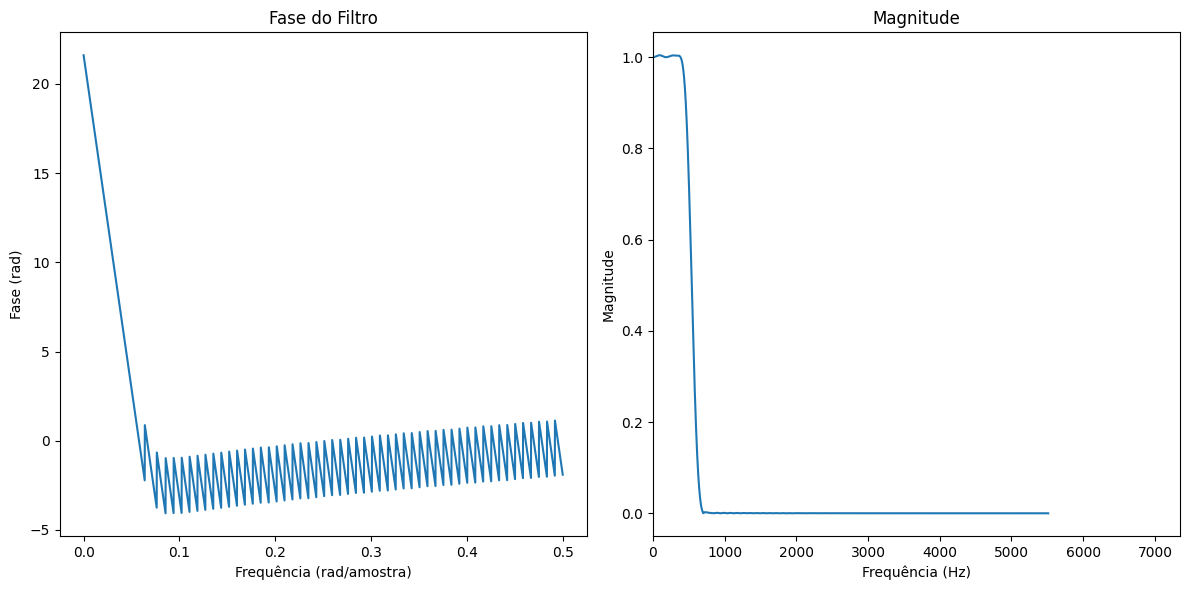

In [370]:
audio_title = "1"
audio_title2 = "2"

plot_mag_phase_hn(audio_title, mag, phase, w, sample_rate)
plot_mag_phase_hn(audio_title2, mag2, phase2, w2, sample_rate_2)

#### 5. Aplicar o filtro projetado e analisar o impacto da qualidade da filtragem ao variar os parâmetros L e ωc.
- Comente os resultados para alguns valores de sua escolha e indique qual o melhor valor obtido.

#### 6. Plotar o sinal filtrado no tempo e na frequência e comparar o antes e depois.

In [ ]:
# Testando filtro passa-baixa criado
filtered_data = np.convolve(data, h) 
filtered_data_2 = np.convolve(data_2, h2) 

write("filtered_audio.wav", sample_rate, filtered_data.astype(np.int16))
write("filtered_audio2.wav", sample_rate_2, filtered_data_2.astype(np.int16))

In [316]:
play('filtered_audio.wav')

In [317]:
play('filtered_audio2.wav')

In [376]:
print(len(t), len(filtered_data))

622173 622272


Imagem salva em: ./images/02_filtered_signal_1.png


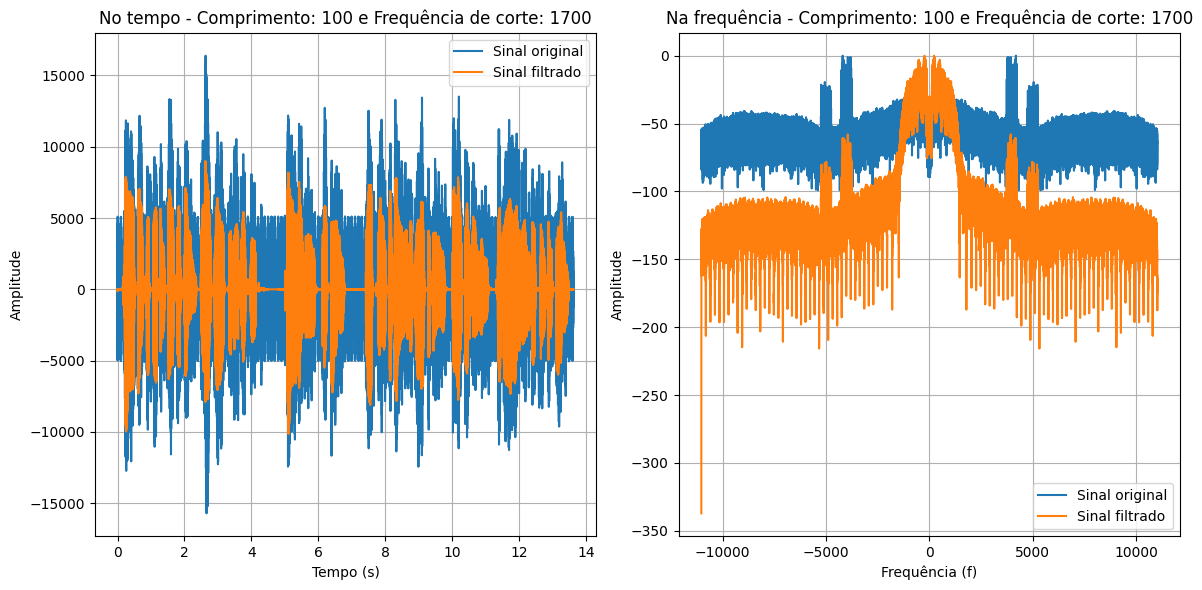

Imagem salva em: ./images/02_filtered_signal_2.png


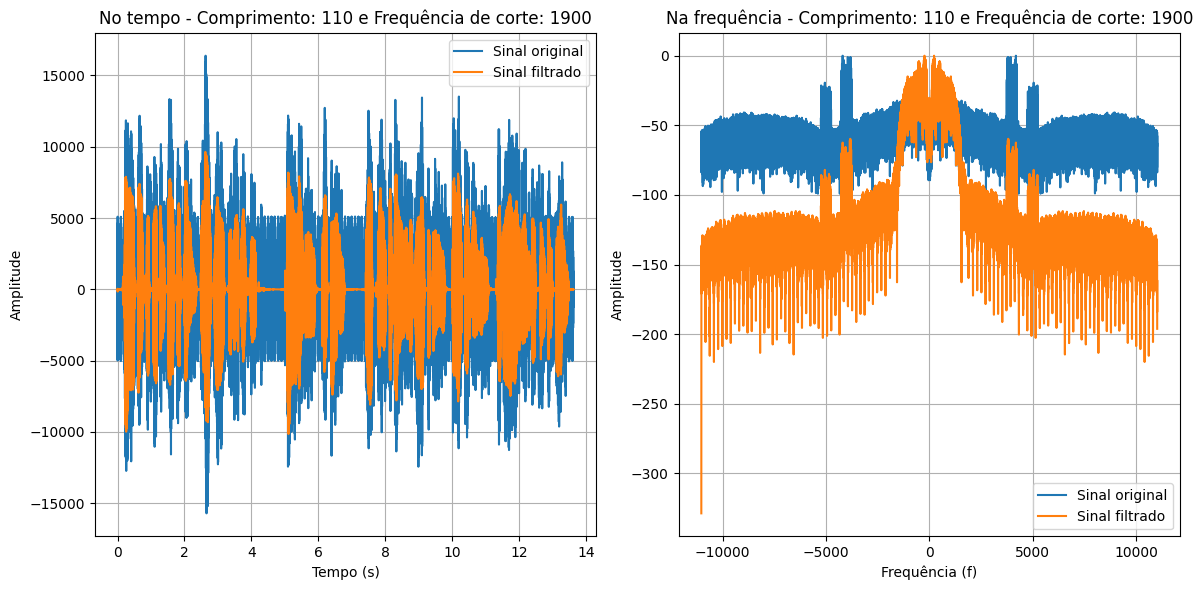

Imagem salva em: ./images/02_filtered_signal_3.png


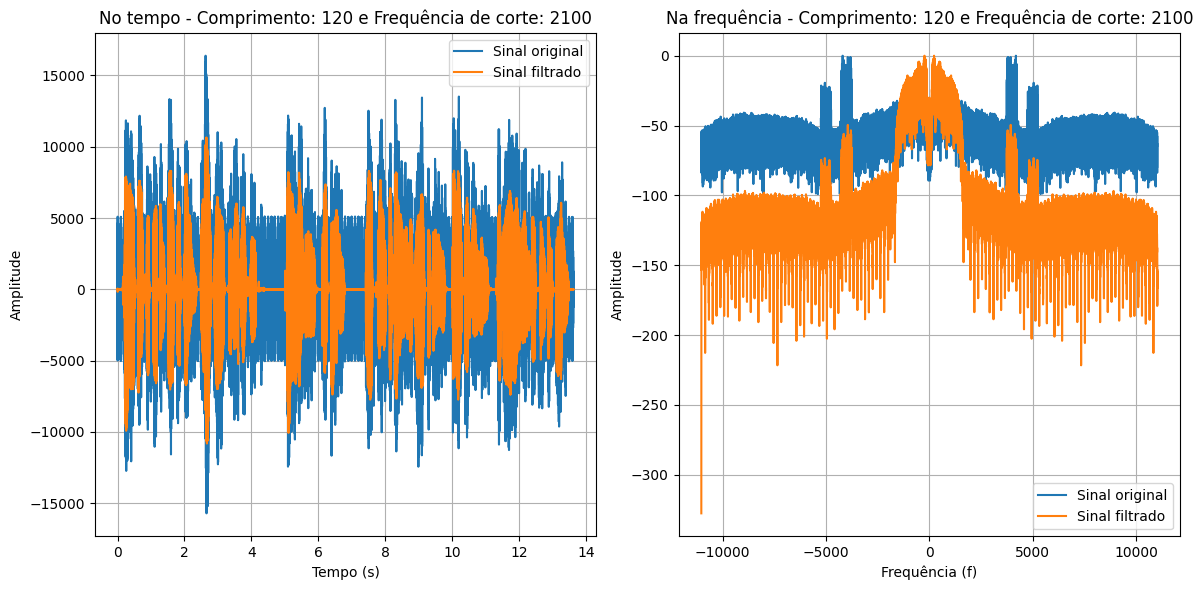

Imagem salva em: ./images/02_filtered_signal_4.png


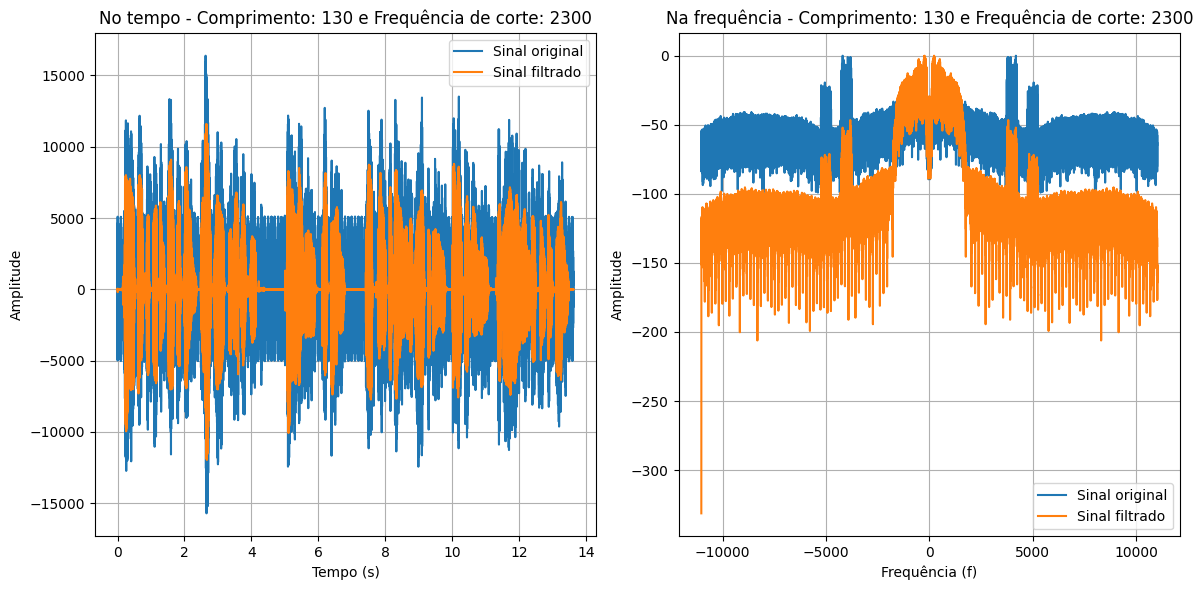

Imagem salva em: ./images/02_filtered_signal_5.png


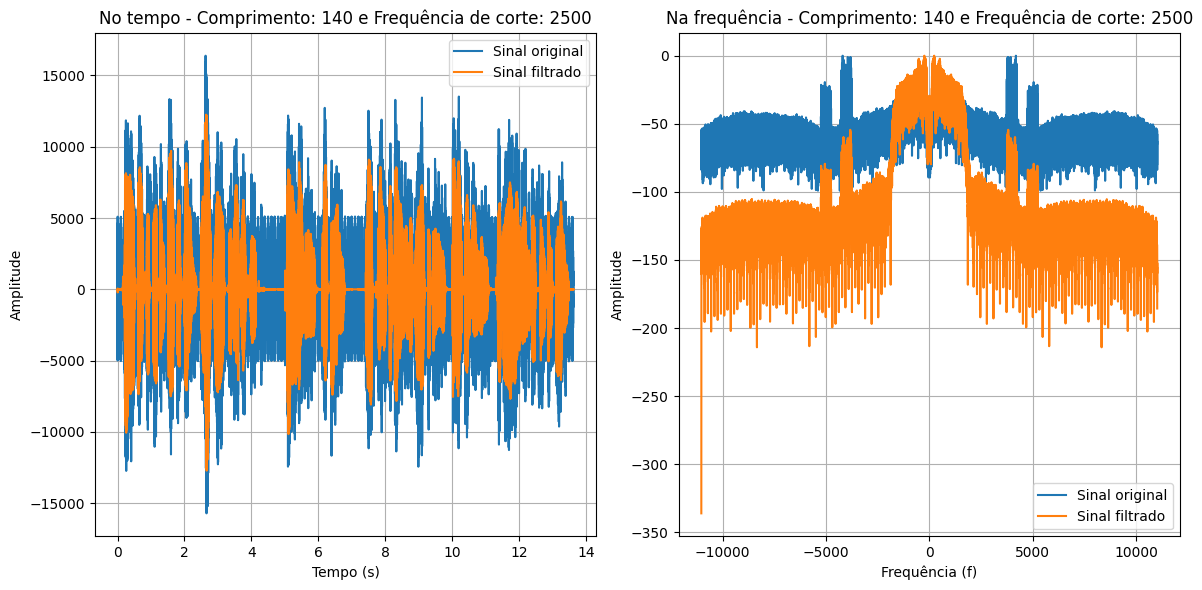

Imagem salva em: ./images/02_filtered_signal_6.png


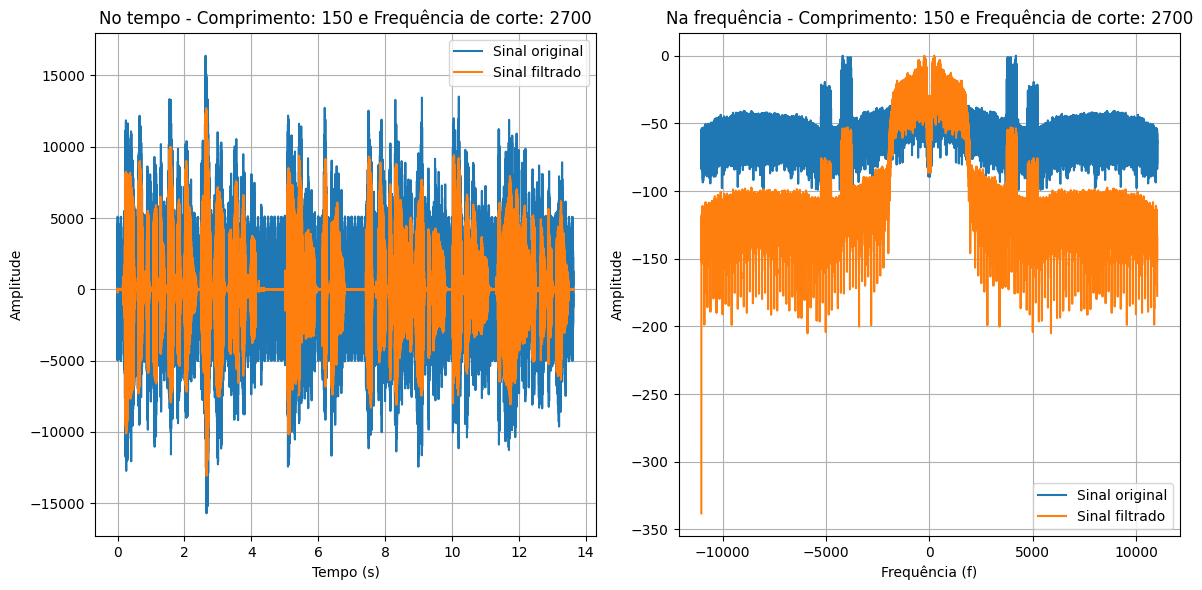

Imagem salva em: ./images/02_filtered_signal_7.png


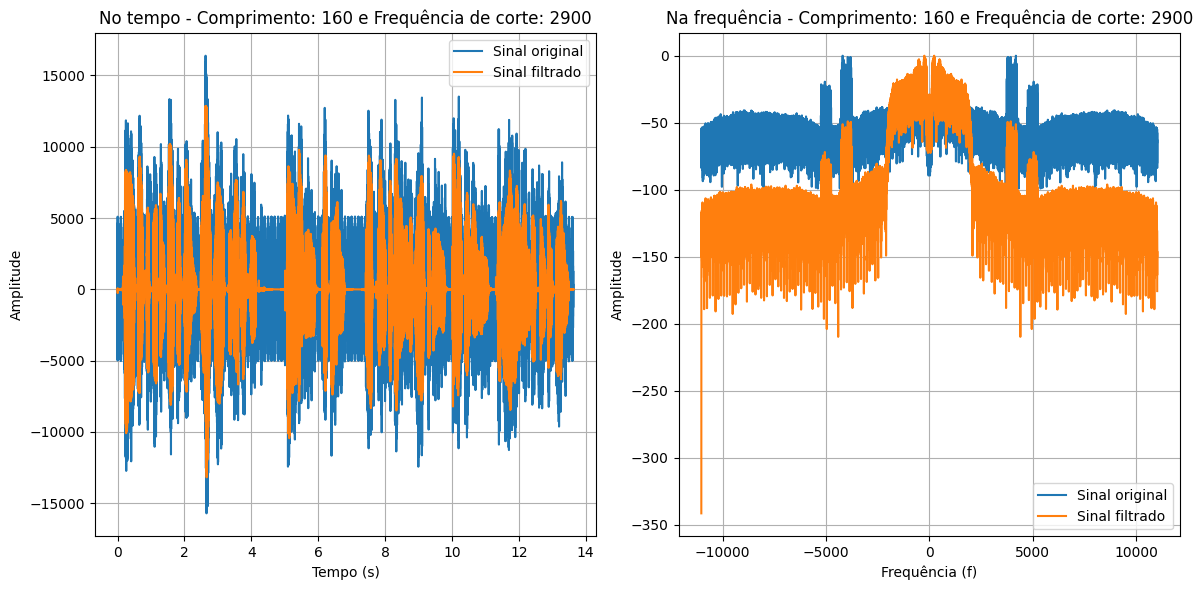

Imagem salva em: ./images/02_filtered_signal_8.png


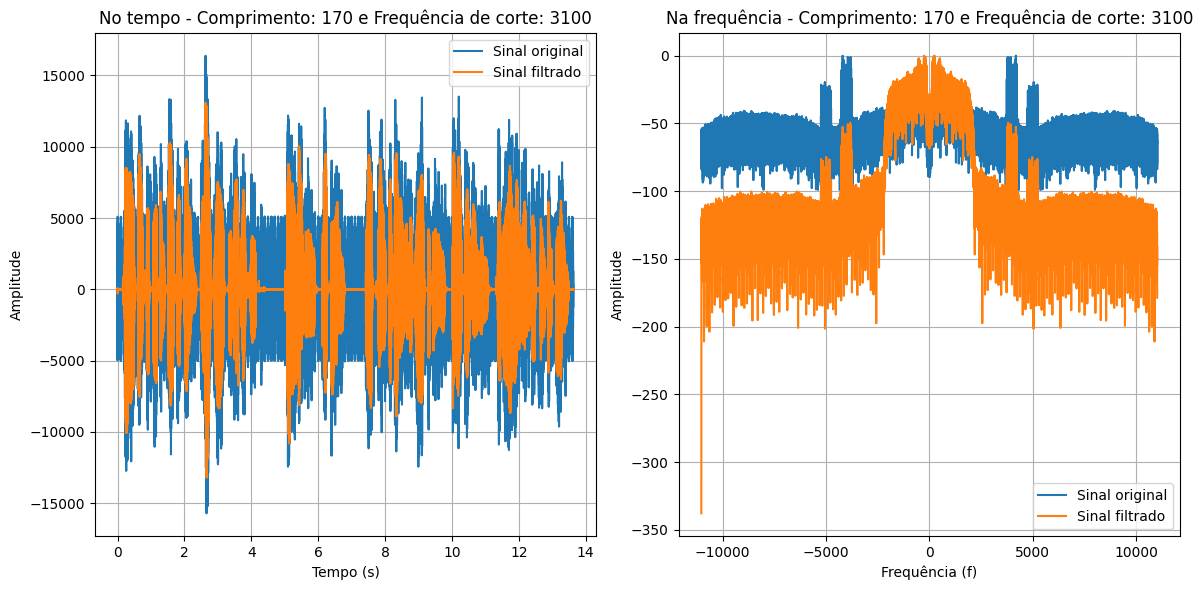

Imagem salva em: ./images/02_filtered_signal_9.png


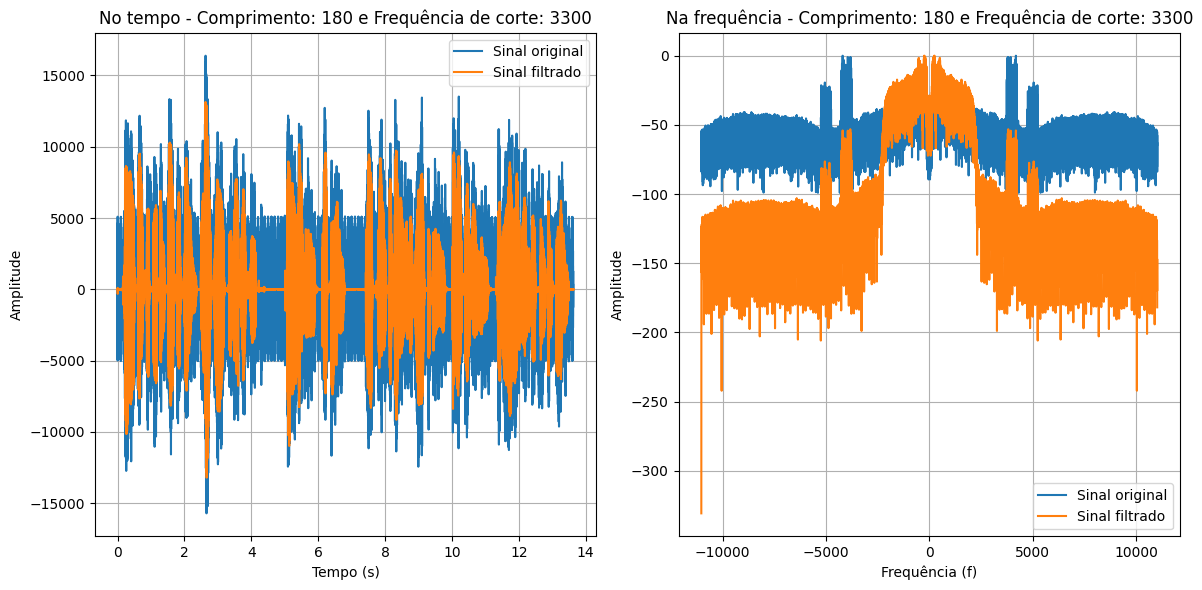

In [389]:
wcs = [1700, 1900, 2100, 2300, 2500, 2700, 2900, 3100, 3300, 3500]
Ms = np.arange(100, 200, 10)
i=0

N = len(data_2)
T = 1/sample_rate_2
t = np.arange(0, N*T, T)

while i < len(Ms)-1:
    h_2, _, _, _ = low_pass_filter(wcs[i], Ms[i], sample_rate_2, plot=False)
    filtered_data_2 = np.convolve(data_2, h_2)
    N_FILTER = len(filtered_data_2)
    t_filter = np.arange(0, N_FILTER*T, T)

    # Plotando sinal original e o filtrado no tempo
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    ax[0].plot(t, data_2, label="Sinal original")
    ax[0].plot(t_filter, filtered_data_2, label='Sinal filtrado')
    ax[0].set_title(f"No tempo - Comprimento: {Ms[i]} e Frequência de corte: {wcs[i]}")
    ax[0].set_xlabel("Tempo (s)")
    ax[0].set_ylabel("Amplitude")
    ax[0].legend()
    ax[0].grid(True)

    # Plotando sinal original e o filtrado na frequência
    f, transf = convert_to_jw(N, T, data_2)
    f_h, transf_h = convert_to_jw(N_FILTER, T, filtered_data_2)

    f_shifted = fftshift(f)
    transf_shifted = fftshift(spectrum(transf))

    f_h_shifted = fftshift(f_h)
    transf_h_shifted = fftshift(spectrum(transf_h))

    ax[1].plot(f_shifted, transf_shifted, label="Sinal original")
    ax[1].plot(f_h_shifted, transf_h_shifted, label='Sinal filtrado')
    ax[1].set_title(f"Na frequência - Comprimento: {Ms[i]} e Frequência de corte: {wcs[i]}")
    ax[1].set_xlabel("Frequência (f)")
    ax[1].set_ylabel("Amplitude")
    ax[1].legend()
    ax[1].grid(True)
    i += 1
    fig.tight_layout()
    savefig(fig, f"./images/02_filtered_signal_{i}.png")
    plt.show()

Imagem salva em: ./images/01_filtered_signal_6quest.png


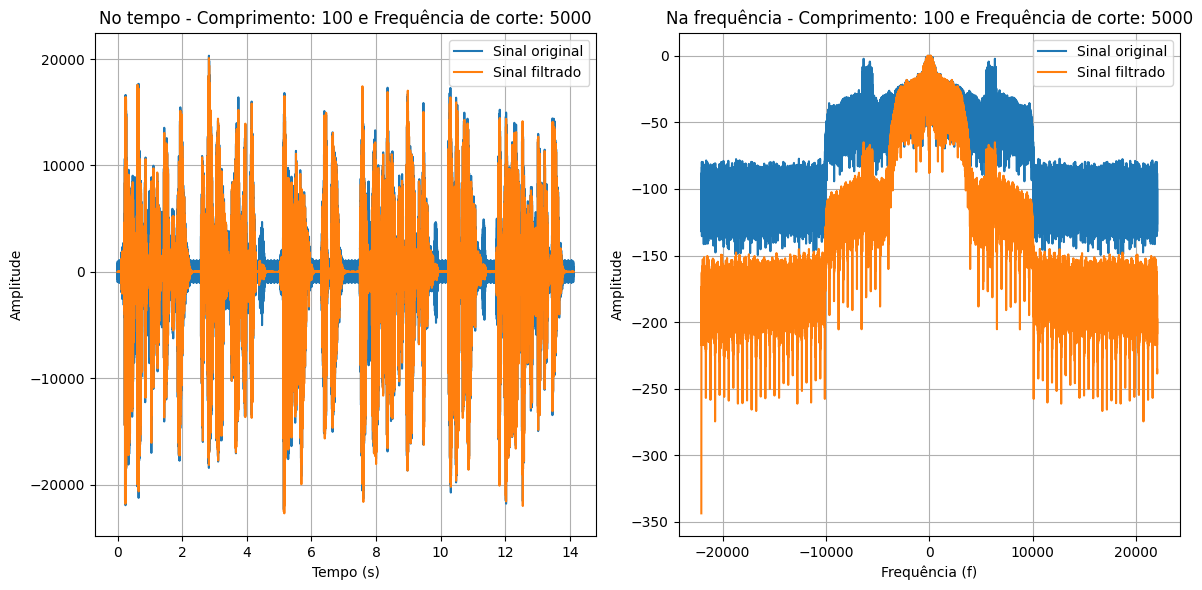

In [430]:
M=100
wc=5000

N = len(data)
T = 1/sample_rate
t = np.arange(0, N*T, T)


h, _, _, _ = low_pass_filter(wc, M, sample_rate, plot=False)
filtered_data = np.convolve(data, h)
N_FILTER = len(filtered_data)
t_filter = np.arange(0, N_FILTER*T, T)

# Plotando sinal original e o filtrado no tempo
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].plot(t, data, label="Sinal original")
ax[0].plot(t_filter, filtered_data, label='Sinal filtrado')
ax[0].set_title(f"No tempo - Comprimento: {M} e Frequência de corte: {wc}")
ax[0].set_xlabel("Tempo (s)")
ax[0].set_ylabel("Amplitude")
ax[0].legend()
ax[0].grid(True)

# Plotando sinal original e o filtrado na frequência
f, transf = convert_to_jw(N, T, data)
f_h, transf_h = convert_to_jw(N_FILTER, T, filtered_data)

f_shifted = fftshift(f)
transf_shifted = fftshift(spectrum(transf))

f_h_shifted = fftshift(f_h)
transf_h_shifted = fftshift(spectrum(transf_h))

ax[1].plot(f_shifted, transf_shifted, label="Sinal original")
ax[1].plot(f_h_shifted, transf_h_shifted, label='Sinal filtrado')
ax[1].set_title(f"Na frequência - Comprimento: {M} e Frequência de corte: {wc}")
ax[1].set_xlabel("Frequência (f)")
ax[1].set_ylabel("Amplitude")
ax[1].legend()
ax[1].grid(True)

fig.tight_layout()
savefig(fig, f"./images/01_filtered_signal_6quest.png")
plt.show()

#### 7. Mensurar de forma subjetiva a qualidade da filtragem ao escutar o áudio filtrado.

In [391]:
play("./data/filtered_audio.wav", rate=sample_rate)

In [392]:
play("./data/filtered_audio2.wav", rate=sample_rate)